In [1]:
import json
import re
import numpy as np
import pandas as pd

In [ ]:
DATA = pd.('../data/processed/integral_dataset.csv', orient='records')
df = pd.DataFrame(DATA)
df['action'] = df['action'].astype(int)
print(f'📦 Tổng mẫu: {len(df)}')
print(f'📊 Phân phối nhãn:\n{df["action"].value_counts().sort_index()}')

AttributeError: module 'pandas' has no attribute 'readcsv'

In [2]:
# Phát hiện mâu thuẫn: cùng integrand, khác action
conflicts = df.groupby('integrand')['action'].nunique()
conflicted = conflicts[conflicts > 1]
print(f'⚠️  Số biểu thức mâu thuẫn nhãn: {len(conflicted)}')
for expr in conflicted.index:
    rows = df[df['integrand'] == expr][['integrand', 'action']]
    print(f"  '{expr}' → actions: {sorted(df[df['integrand']==expr]['action'].unique())}")

print()

# Xử lý mâu thuẫn: lấy nhãn phổ biến nhất (majority vote)
def majority_label(group):
    return group['action'].mode()[0]

df_clean = df.groupby('integrand').apply(majority_label).reset_index()
df_clean.columns = ['integrand', 'action']
print(f'✅ Sau dedup (majority vote): {len(df_clean)} mẫu unique')
print(f'📊 Phân phối nhãn sau làm sạch:\n{df_clean["action"].value_counts().sort_index()}')


NameError: name 'df' is not defined

In [ ]:
df_clean = 

NameError: name 'df_clean' is not defined

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


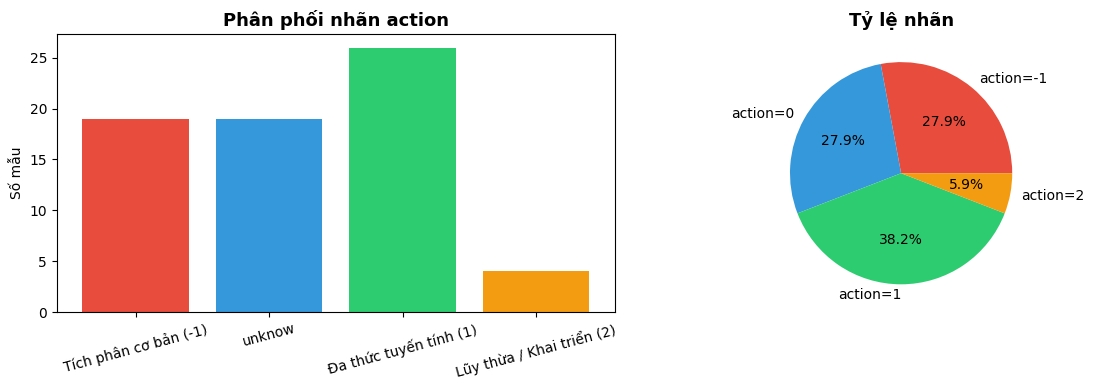

✅ Đã lưu label_distribution.png


In [12]:
%pip install matplotlib
from collections import Counter
y = df_clean['action']
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_names = {-1: 'Tích phân cơ bản (-1)', 
                0: 'unknow', 
                1: 'Đa thức tuyến tính (1)', 
                2: 'Lũy thừa / Khai triển (2)'}

counts = Counter(y)
labels = sorted(counts.keys())
values = [counts[l] for l in labels]
names  = [label_names.get(l, str(l)) for l in labels]

axes[0].bar(names, values, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title('Phân phối nhãn action', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số mẫu')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(values, labels=[f'action={l}' for l in labels], autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1].set_title('Tỷ lệ nhãn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu label_distribution.png')

In [ ]:
%pip install scikit-learn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

X_df = df_clean['integrand'].apply(extract_features).apply(pd.Series)
X = X_df.values

# Tính class weights để xử lý mất cân bằng
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
cw_dict = dict(zip(np.unique(y), class_weights))
print('⚖️  Class weights:', cw_dict)

# Train/test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n🔀 Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 8.5 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.1 MB 7.7 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 7.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 7.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 5.8 MB/s eta 0:00:07
   --- ------------------------------------ 2.9/37.3 MB 6.7 MB/s eta 0:00:06
   ----- ---------------------------------- 4.7/37.3 MB 7.2 MB/s eta 0:00:05
   ------ --------------------------------- 5.8/37.3 MB 6.9 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/37.3 MB 7.0 MB/s eta 0:00:05
   --------- ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


⚖️  Class weights: {-1: 0.8947368421052632, 0: 0.8947368421052632, 1: 0.6538461538461539, 2: 4.25}

🔀 Train: 54 | Test: 14


In [18]:
# Pipeline: StandardScaler + SVM
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

# Grid search parameters
param_grid = [
    {
        'svm__kernel': ['rbf'],
        'svm__C':      [0.1, 1, 10, 100],
        'svm__gamma':  ['scale', 'auto', 0.01, 0.1]
    },
    {
        'svm__kernel': ['linear'],
        'svm__C':      [0.1, 1, 10]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C':      [0.1, 1, 10],
        'svm__degree': [2, 3]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svm_pipeline, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

print('🔍 Đang chạy GridSearchCV...')
grid_search.fit(X_train, y_train)

print(f'\n🏆 Best params: {grid_search.best_params_}')
print(f'🏆 Best CV F1 (macro): {grid_search.best_score_:.4f}')

🔍 Đang chạy GridSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\giaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



🏆 Best params: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
🏆 Best CV F1 (macro): 0.6348
